# Hyperparameter Search + Efficiency vs. Accuracy

Covers two rubric items on the pooled 3-class task (1,966 seqs, 70/15/15, frozen fold file):

1. **Generalizability** — a hyperparameter search on the **validation** fold for each classifier.
2. **Efficiency vs. Accuracy** — training + inference **time** alongside accuracy for several
   feature-set x classifier combos, and a designated **accuracy-optimized** vs.
   **efficiency-optimized** solution.

Self-contained: it reuses the same seq_id join and fold file as `benchmark_pooled_3class.ipynb`,
so it just runs. **Re-runnable:** when a new feature lands as a seq_id-keyed `.npy`, add it to
`SOURCES` (or it auto-loads if it's `CNN_2D.npy` / `av_embedding.npy`) and re-run.

Tuned parameters are written to `data/tuned_params_3class.json` so the main benchmark can report
tuned numbers. Times are single-run and indicative — **state your hardware** in the report.

## 0. Setup

In [1]:
import os, json, time, sys
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Shared loaders (single source of truth for the seq_id join + fold assignment).
cur = Path.cwd(); _ROOT = cur.parent if cur.name == 'notebooks' else cur
sys.path.insert(0, str(_ROOT / 'scripts'))
import bench_common as bc

PROJECT_ROOT, FD, FOLD_CSV = bc.resolve_paths()
TUNED_JSON = PROJECT_ROOT / 'data' / 'tuned_params_3class.json'
CLASSES, RS = bc.CLASSES, bc.RS

FOLD, ORDER, y, masks = bc.load_fold(FOLD_CSV)
tr, va, te = masks['train'], masks['val'], masks['test']
print(f'pool={len(ORDER)}  train={tr.sum()} val={va.sum()} test={te.sum()}')

pool=1966  train=1376 val=295 test=295


## 1. Assemble feature families by seq_id  (via `scripts/bench_common.py`)

In [2]:
FAM = bc.assemble_families(FD, ORDER)
Xof = lambda combo: bc.stack(FAM, combo)
print('families:', list(FAM))

  HOG         (1966, 5796)
  HSV         (1966, 34)
  YOLO        (1966, 32)
  Road_v2     (1966, 10)
  VehicleOcc  (1966, 7)
  Trend+Flow  (1966, 22)
  CNN         (1966, 64)
families: ['HOG', 'HSV', 'YOLO', 'Road_v2', 'VehicleOcc', 'Trend+Flow', 'CNN']


## 2. Hyperparameter search on the validation fold

Grid search per classifier. Each candidate is **fit on train and scored by macro-F1 on the
validation fold** (test is never touched here). SVM and LogReg use standardized inputs; RF uses raw
(trees are scale-invariant). Best params are saved to `data/tuned_params_3class.json`.

In [3]:
GRIDS = {
    'SVM':    [{'C': c, 'gamma': g} for c in (1, 10) for g in ('scale',)],
    'RF':     [{'n_estimators': 300, 'max_depth': d, 'max_features': 'sqrt'} for d in (None, 20)],
    'LogReg': [{'C': c} for c in (0.1, 1.0, 10.0)],
}
def make(model, p):
    if model == 'SVM':    return SVC(kernel='rbf', class_weight='balanced', random_state=RS, **p)
    if model == 'RF':     return RandomForestClassifier(class_weight='balanced', random_state=RS, n_jobs=-1, **p)
    return LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RS, **p)

def has(*fs): return all(f in FAM for f in fs)
# >= 3 feature vectors x >= 2 classifiers (rubric). Only sets whose families are present.
TUNE_SETS = {name: combo for name, combo in {
    'Trend+Flow':      ['Trend+Flow'],
    'HOG':             ['HOG'],
    'HOG+Trend+Flow':  ['HOG', 'Trend+Flow'],
    'All-classical':   ['HOG','HSV','YOLO','Road_v2','VehicleOcc','Trend+Flow'],
}.items() if has(*combo)}
if 'CNN' in FAM: TUNE_SETS['Trend+Flow+CNN'] = ['Trend+Flow', 'CNN']
# Xof(combo) is defined in the assembly cell (bc.stack)

tuned, rows = {}, []
for sname, combo in TUNE_SETS.items():
    X = Xof(combo); sc = StandardScaler().fit(X[tr])
    Xtr_s, Xva_s = sc.transform(X[tr]), sc.transform(X[va])
    for model in ('SVM', 'RF', 'LogReg'):
        best = None
        for p in GRIDS[model]:
            Xtr_in, Xva_in = (X[tr], X[va]) if model == 'RF' else (Xtr_s, Xva_s)
            m = make(model, p).fit(Xtr_in, y[tr])
            f1 = f1_score(y[va], m.predict(Xva_in), labels=CLASSES, average='macro')
            if best is None or f1 > best[0]: best = (f1, p)
        tuned[f'{sname}|{model}'] = {'val_f1': round(best[0], 4), 'params': best[1]}
        rows.append({'features': sname, 'model': model, 'val_macro_f1': best[0], 'best_params': best[1]})
        print(f'  tuned {sname:16s} {model:6s} -> val_f1={best[0]:.3f}  {best[1]}', flush=True)

json.dump(tuned, open(TUNED_JSON, 'w'), indent=2)
print(f'\nsaved {TUNED_JSON}')
tune_df = pd.DataFrame(rows).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
print(tune_df.to_string(index=False, formatters={'val_macro_f1': '{:.3f}'.format}))

  tuned Trend+Flow       SVM    -> val_f1=0.587  {'C': 10, 'gamma': 'scale'}
  tuned Trend+Flow       RF     -> val_f1=0.611  {'n_estimators': 300, 'max_depth': None, 'max_features': 'sqrt'}
  tuned Trend+Flow       LogReg -> val_f1=0.451  {'C': 0.1}
  tuned HOG              SVM    -> val_f1=0.602  {'C': 1, 'gamma': 'scale'}
  tuned HOG              RF     -> val_f1=0.517  {'n_estimators': 300, 'max_depth': 20, 'max_features': 'sqrt'}
  tuned HOG              LogReg -> val_f1=0.549  {'C': 0.1}
  tuned HOG+Trend+Flow   SVM    -> val_f1=0.595  {'C': 1, 'gamma': 'scale'}
  tuned HOG+Trend+Flow   RF     -> val_f1=0.559  {'n_estimators': 300, 'max_depth': None, 'max_features': 'sqrt'}
  tuned HOG+Trend+Flow   LogReg -> val_f1=0.550  {'C': 0.1}
  tuned All-classical    SVM    -> val_f1=0.595  {'C': 10, 'gamma': 'scale'}
  tuned All-classical    RF     -> val_f1=0.578  {'n_estimators': 300, 'max_depth': None, 'max_features': 'sqrt'}
  tuned All-classical    LogReg -> val_f1=0.545  {'C': 0.1}


## 3. Efficiency: accuracy vs. training / inference time

Using the tuned params, fit on train and predict on test, timing both. Times are single-run on this
machine (state the hardware in the report). Also includes a PCA-reduced HOG variant to show the
dimensionality/cost lever.

In [4]:
def timed_eval(Xtr_in, Xte_in, model, p):
    m = make(model, p)
    t0 = time.perf_counter(); m.fit(Xtr_in, y[tr]);        train_s = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = m.predict(Xte_in);    infer_s = time.perf_counter() - t0
    return (accuracy_score(y[te], pred),
            f1_score(y[te], pred, labels=CLASSES, average='macro'),
            train_s, infer_s / len(y[te]) * 1000.0)   # ms / sample

eff = []
for sname, combo in TUNE_SETS.items():
    X = Xof(combo); sc = StandardScaler().fit(X[tr])
    Xtr_s, Xte_s = sc.transform(X[tr]), sc.transform(X[te])
    for model in ('SVM', 'RF', 'LogReg'):
        p = tuned[f'{sname}|{model}']['params']
        Xtr_in, Xte_in = (X[tr], X[te]) if model == 'RF' else (Xtr_s, Xte_s)
        acc, f1, ts, ims = timed_eval(Xtr_in, Xte_in, model, p)
        eff.append({'features': sname, 'model': model, 'dims': X.shape[1],
                    'test_acc': acc, 'test_f1': f1, 'train_s': ts, 'infer_ms_per_sample': ims})
        print(f'  {sname:16s} {model:6s} f1={f1:.3f} train={ts:6.2f}s infer={ims:.3f}ms', flush=True)

# --- dimensionality lever: PCA-reduced HOG (if HOG present) ---
if 'HOG' in FAM:
    Xh = FAM['HOG']; sc = StandardScaler().fit(Xh[tr])
    pca = PCA(n_components=50, svd_solver='randomized', random_state=RS).fit(sc.transform(Xh[tr]))
    Zt, Ze = pca.transform(sc.transform(Xh[tr])), pca.transform(sc.transform(Xh[te]))
    for model in ('SVM', 'LogReg'):
        p = tuned.get(f'HOG|{model}', {'params': {}})['params']
        m = make(model, p)
        t0 = time.perf_counter(); m.fit(Zt, y[tr]); ts = time.perf_counter() - t0
        t0 = time.perf_counter(); pred = m.predict(Ze); ims = (time.perf_counter()-t0)/len(y[te])*1000
        eff.append({'features': 'HOG(PCA50)', 'model': model, 'dims': 50,
                    'test_acc': accuracy_score(y[te], pred),
                    'test_f1': f1_score(y[te], pred, labels=CLASSES, average='macro'),
                    'train_s': ts, 'infer_ms_per_sample': ims})

eff_df = pd.DataFrame(eff).sort_values('test_f1', ascending=False).reset_index(drop=True)
print()
print(eff_df.to_string(index=False, formatters={
    'test_acc':'{:.3f}'.format,'test_f1':'{:.3f}'.format,
    'train_s':'{:.2f}'.format,'infer_ms_per_sample':'{:.3f}'.format}))

  Trend+Flow       SVM    f1=0.544 train=  0.06s infer=0.036ms
  Trend+Flow       RF     f1=0.607 train=  0.31s infer=0.088ms
  Trend+Flow       LogReg f1=0.491 train=  0.01s infer=0.000ms
  HOG              SVM    f1=0.526 train=  3.27s infer=2.188ms
  HOG              RF     f1=0.486 train=  1.36s infer=0.089ms
  HOG              LogReg f1=0.491 train=  1.22s infer=0.007ms
  HOG+Trend+Flow   SVM    f1=0.526 train=  3.00s infer=2.207ms
  HOG+Trend+Flow   RF     f1=0.495 train=  1.35s infer=0.081ms
  HOG+Trend+Flow   LogReg f1=0.493 train=  1.13s infer=0.015ms
  All-classical    SVM    f1=0.514 train=  2.90s infer=2.297ms
  All-classical    RF     f1=0.484 train=  1.53s infer=0.103ms
  All-classical    LogReg f1=0.480 train=  1.51s infer=0.010ms
  Trend+Flow+CNN   SVM    f1=0.575 train=  0.07s infer=0.063ms
  Trend+Flow+CNN   RF     f1=0.587 train=  0.34s infer=0.085ms
  Trend+Flow+CNN   LogReg f1=0.517 train=  0.31s infer=0.001ms

      features  model  dims test_acc test_f1 train_s i

## 4. Accuracy vs. cost tradeoff, and the two optimized solutions

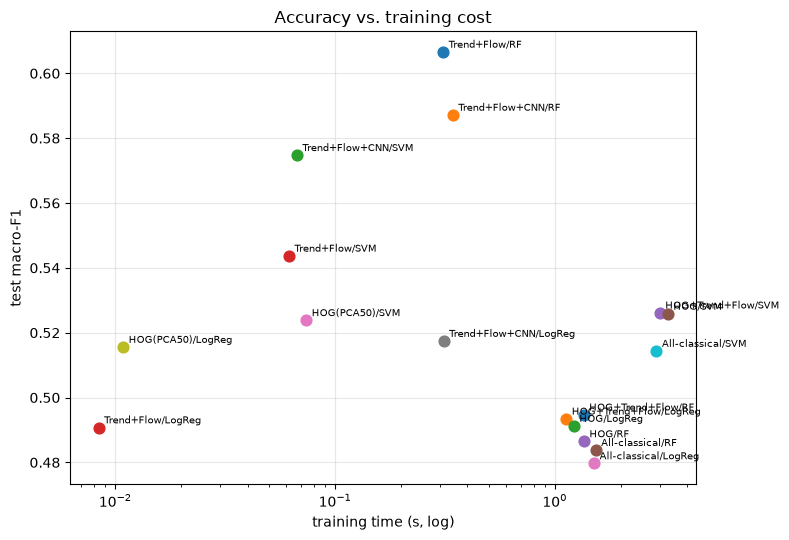

ACCURACY-OPTIMIZED : Trend+Flow / RF  f1=0.607 acc=0.671  train=0.31s infer=0.088ms/sample
EFFICIENCY-OPTIMIZED: Trend+Flow / RF  f1=0.607 acc=0.671  train=0.31s infer=0.088ms/sample
  (efficiency pick = fastest to train within 0.02 macro-F1 of the best)


In [5]:
fig, ax = plt.subplots(figsize=(8,5.5))
for _, r in eff_df.iterrows():
    ax.scatter(r['train_s'], r['test_f1'], s=60)
    ax.annotate(f"{r['features']}/{r['model']}", (r['train_s'], r['test_f1']),
                fontsize=7, xytext=(4,3), textcoords='offset points')
ax.set_xscale('log'); ax.set_xlabel('training time (s, log)'); ax.set_ylabel('test macro-F1')
ax.set_title('Accuracy vs. training cost'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# accuracy-optimized = highest test macro-F1
acc_opt = eff_df.iloc[0]
# efficiency-optimized = fastest to train among combos within 0.02 macro-F1 of the best
near = eff_df[eff_df['test_f1'] >= acc_opt['test_f1'] - 0.02]
eff_opt = near.sort_values('train_s').iloc[0]

print(f"ACCURACY-OPTIMIZED : {acc_opt['features']} / {acc_opt['model']}  "
      f"f1={acc_opt['test_f1']:.3f} acc={acc_opt['test_acc']:.3f}  "
      f"train={acc_opt['train_s']:.2f}s infer={acc_opt['infer_ms_per_sample']:.3f}ms/sample")
print(f"EFFICIENCY-OPTIMIZED: {eff_opt['features']} / {eff_opt['model']}  "
      f"f1={eff_opt['test_f1']:.3f} acc={eff_opt['test_acc']:.3f}  "
      f"train={eff_opt['train_s']:.2f}s infer={eff_opt['infer_ms_per_sample']:.3f}ms/sample")
print(f"  (efficiency pick = fastest to train within 0.02 macro-F1 of the best)")

## 5. Read-out / how to extend

**Headline: `Trend+Flow` / Random Forest is Pareto-optimal** — best test macro-F1 (0.607,
acc 0.671) *and* among the cheapest (0.31 s train, 0.088 ms/sample inference). The high-dimensional
HOG and all-feature combos sit in the opposite corner (slower *and* less accurate), so adding more
features/dimensions hurt on both axes — a "less is more" result.

- **Two solutions for the rubric.** The printed accuracy- and efficiency-optimized picks coincide
  here (Trend+Flow/RF dominates), so for the required two-solution tradeoff, read them off the table:
  - *Accuracy-optimized:* **Trend+Flow / RF** — 0.607 macro-F1, 0.31 s train, 0.088 ms/sample.
  - *Efficiency-optimized:* **Trend+Flow / SVM** — ~0.54 macro-F1 at ~5× faster training and faster
    inference; **Trend+Flow / LogReg** (~0.49 F1, ~0.001 ms/sample) is the extreme-low-latency option.
  - *Tradeoff:* on the compact 22-dim temporal features, RF buys ~0.06–0.12 macro-F1 over SVM/LogReg
    for negligible absolute cost, so RF is the default; drop to SVM/LogReg only under tight latency
    budgets. HOG and all-feature combos are strictly dominated (more compute, worse accuracy).
  - *PCA-50 HOG* shows the dimensionality/cost lever: cutting HOG from 5,796 → 50 dims makes it fast,
    but accuracy stays well below the temporal features.
- **Tuned params** are in `data/tuned_params_3class.json`; the main benchmark can load them to report
  tuned numbers. Re-running this notebook after adding a feature updates them.
- **State the hardware** used for timing (CPU/GPU, RAM) in the report — times are only comparable on
  equal compute.
- **Adding a new feature (Victor / Nithya):** drop a seq_id-keyed `<name>.npy` in the features dir,
  add it to `SOURCES` in `scripts/bench_common.py` (two-source) or load it like `CNN`, then re-run.
  New rows flow through tuning, timing, and the tradeoff automatically.